In [1]:
#import libraries
import numpy as np
import matplotlib.pylab as plt
import librosa
import librosa.display
import IPython.display

#import audio files
!git clone https://github.com/jcdevaney/musicComputing2026.git

Cloning into 'musicComputing2026'...
remote: Enumerating objects: 136, done.
remote: Counting objects: 100% (136/136), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 136 (delta 59), reused 10 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (136/136), 21.22 MiB | 9.61 MiB/s, done.
Resolving deltas: 100% (59/59), done.


In [2]:
def plotAudio2(sig,sampleRate,title):


   # this version expects the audio file to have already been opened by librosa


   # Adjust the x-axis to represent time


   time=np.arange(0,sig.shape[0])/sampleRate


   # Scale the y-axis to represent amplitude from -1 to 1
   excursion=max(abs(sig))
   sigNew = sig / excursion


   # Label the x and y axes with variables
   xlabel = 'Time (seconds)'
   ylabel = 'Amplitude'


   #plot the signal using the x and y axis variables
   plt.plot(time,sigNew)
   plt.xlabel(xlabel)
   plt.ylabel(ylabel)
   plt.title(title)
   plt.show()

In [3]:
def plotAudioFreqDomain(sig,sr,title,winSize,specType):
  spec = librosa.amplitude_to_db(np.abs(librosa.stft(sig,n_fft=winSize)),ref=np.max)

  librosa.display.specshow(spec, y_axis=specType)
  plt.colorbar(format='%+2.0f dB')
  plt.title(f'{specType} power spectrogram')
  plt.show()
    # create a normalized spectrogram
    # this includes several function calls
    # first create a basic spectrogram with librosa.stft() with the default window size (2048)

In [4]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):

    # generate list of harmonics
    harmonics = np.arange(1,numHarmonics+1,seqHarm)
    harmonics = harmonics[1:-1]

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot

    return signal

In [5]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):

  if waveType == 'sawtooth':
     seqHarm = 1
     ampExponent = 1
  elif waveType == 'square':
     seqHarm = 2
     ampExponent = 1
  elif waveType == 'triangle':
     seqHarm = 2
     ampExponent = 2
  else:
     numHarmonics = 1
     seqHarm = 1
     ampExponent = 1

  signal=additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)

  return signal

In [6]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, winSize, waveType):

  sig = makeWaveforms(frequency,samplingRate,numHarmonics,waveType)


  plotAudio2(sig,samplingRate,waveType)

  plotAudioFreqDomain(sig,samplingRate,numHarmonics,winSize,specType)

  return sig

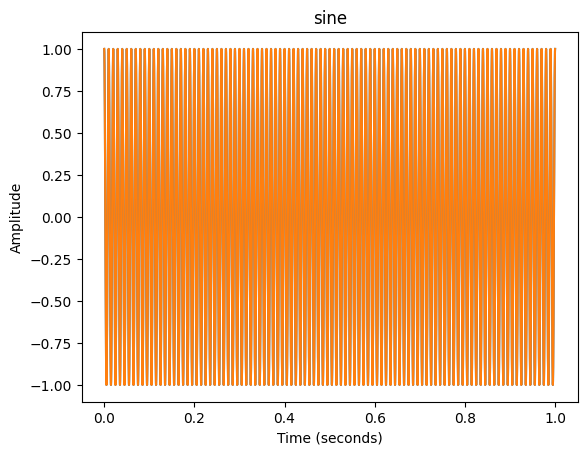

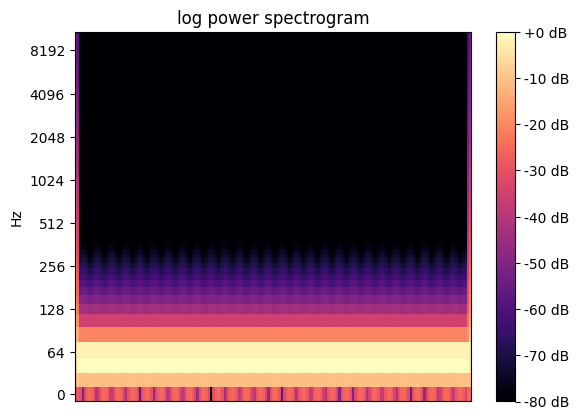

In [7]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'
sig =visualizeWaveforms(frequency,samplingRate,numHarmonics,winSize,waveType)
IPython.display.Audio(sig,rate=samplingRate)

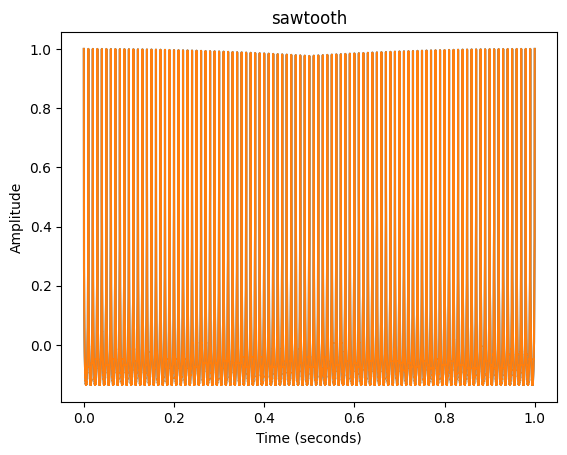

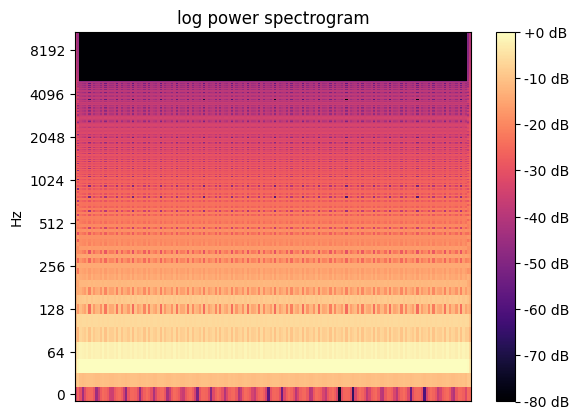

In [9]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

sig =visualizeWaveforms(frequency,samplingRate,numHarmonics,winSize,waveType)
IPython.display.Audio(sig,rate=samplingRate)

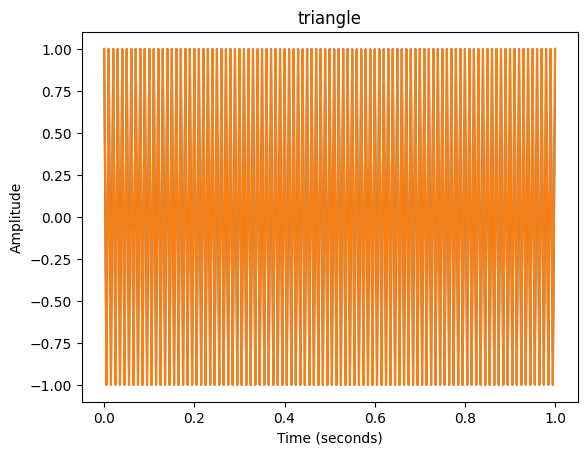

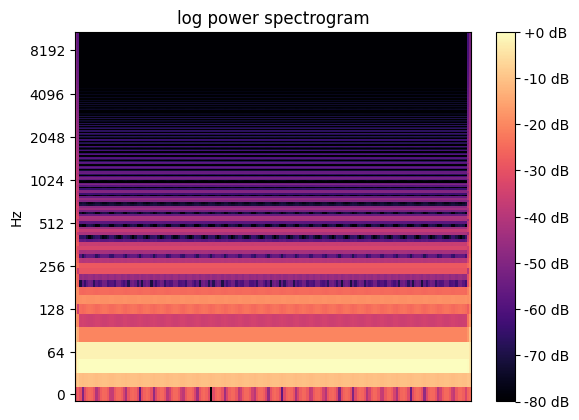

In [10]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

sig =visualizeWaveforms(frequency,samplingRate,numHarmonics,winSize,waveType)
IPython.display.Audio(sig,rate=samplingRate)

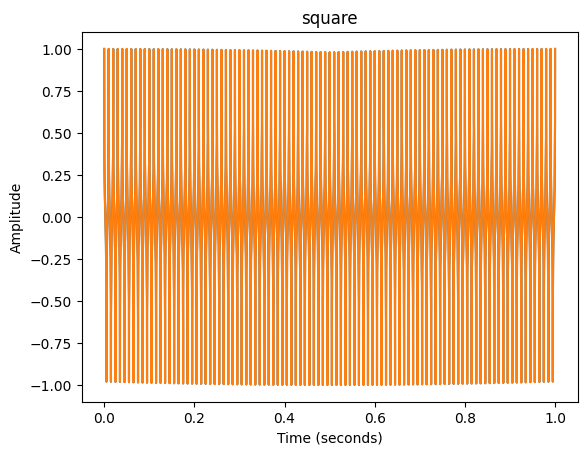

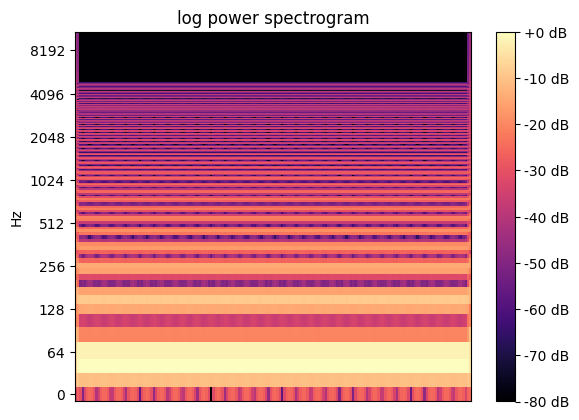

In [11]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

sig =visualizeWaveforms(frequency,samplingRate,numHarmonics,winSize,waveType)
IPython.display.Audio(sig,rate=samplingRate)